In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 73.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=3b3e2063f66f6d400d4834498eddef42ca3b66ff645ba34e73af19ae2dc02de1
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

# The aim of the assignment is to simulate the Ekert91 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

# BB84, with attacker

Same BB84 protocol but with Eve doing intercept-resend in the middle. N = 200 (bigger than the plain run so attack detection is reliable).

## Quantum RNG

In [3]:
from qiskit_aer import AerSimulator
simulator = AerSimulator()

def quantum_random_bit():
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)
    return int(simulator.run(transpile(qc, simulator), shots=1, memory=True).result().get_memory()[0])

def quantum_random_bits(n, chunk=20):
    bits = []
    while n > 0:
        k = min(chunk, n)
        qc = QuantumCircuit(k, k)
        for q in range(k):
            qc.h(q)
        qc.measure(range(k), range(k))
        bs = simulator.run(transpile(qc, simulator), shots=1, memory=True).result().get_memory()[0]
        bits.extend(int(c) for c in bs[::-1])
        n -= k
    return bits

print("sample:", quantum_random_bits(10))

sample: [0, 1, 1, 1, 1, 1, 1, 0, 0, 0]


## Alice

In [4]:
N = 200

alice_bits  = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)   # 0 = standard (Z), 1 = diagonal (X)

def alice_encode(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

alice_circuits = [alice_encode(b, ba) for b, ba in zip(alice_bits, alice_bases)]

basis_name = {0: "Z", 1: "X"}
state_name = {(0, 0): "|0>", (1, 0): "|1>", (0, 1): "|+>", (1, 1): "|->"}

print(f"Alice prepared {N} qubits. First 10:")
print(f"{'i':>3} {'bit':>4} {'basis':>6} {'state':>6}")
for i in range(10):
    print(f"{i:>3} {alice_bits[i]:>4} {basis_name[alice_bases[i]]:>6} {state_name[(alice_bits[i], alice_bases[i])]:>6}")

Alice prepared 200 qubits. First 10:
  i  bit  basis  state
  0    0      X    |+>
  1    1      X    |->
  2    0      Z    |0>
  3    1      X    |->
  4    0      Z    |0>
  5    0      X    |+>
  6    1      X    |->
  7    1      X    |->
  8    0      X    |+>
  9    1      X    |->


## Eve (intercept-resend)

Measures Alice's qubit in a random basis, then sends Bob a fresh qubit prepared in whatever she measured.

In [5]:
eve_bases = quantum_random_bits(N)

def eve_intercept(prepared_circuit, basis):
    qc = prepared_circuit.copy()
    if basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=1, memory=True).result()
    eve_bit = int(result.get_memory()[0])

    new_qc = QuantumCircuit(1, 1)
    if eve_bit == 1:
        new_qc.x(0)
    if basis == 1:
        new_qc.h(0)
    return eve_bit, new_qc

eve_bits = []
eve_circuits = []
for ac, eb in zip(alice_circuits, eve_bases):
    bit, qc = eve_intercept(ac, eb)
    eve_bits.append(bit)
    eve_circuits.append(qc)

print(f"Eve intercepted {N} qubits. First 10:")
print(f"{'i':>3} {'eve_basis':>10} {'eve_bit':>8}")
for i in range(10):
    print(f"{i:>3} {basis_name[eve_bases[i]]:>10} {eve_bits[i]:>8}")

Eve intercepted 200 qubits. First 10:
  i  eve_basis  eve_bit
  0          X        0
  1          Z        0
  2          X        0
  3          Z        1
  4          Z        0
  5          Z        0
  6          Z        0
  7          Z        0
  8          X        0
  9          Z        1


## Bob

In [6]:
bob_bases = quantum_random_bits(N)

def bob_measure(prepared_circuit, basis):
    qc = prepared_circuit.copy()
    if basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=1, memory=True).result()
    return int(result.get_memory()[0])

bob_bits = [bob_measure(qc, ba) for qc, ba in zip(eve_circuits, bob_bases)]

print(f"Bob measured {N} qubits. First 10 results:")
print(f"{'i':>3} {'bob_basis':>10} {'bob_bit':>8}")
for i in range(10):
    print(f"{i:>3} {basis_name[bob_bases[i]]:>10} {bob_bits[i]:>8}")

Bob measured 200 qubits. First 10 results:
  i  bob_basis  bob_bit
  0          Z        1
  1          Z        0
  2          X        0
  3          Z        1
  4          Z        0
  5          X        0
  6          Z        0
  7          Z        0
  8          X        0
  9          X        1


## Sifting

In [7]:
matching_indices = [i for i in range(N) if alice_bases[i] == bob_bases[i]]

alice_sifted = [alice_bits[i] for i in matching_indices]
bob_sifted   = [bob_bits[i]   for i in matching_indices]

print(f"Out of {N} qubits, {len(matching_indices)} survived sifting "
      f"({100 * len(matching_indices) / N:.0f}%).")
print(f"Alice's sifted bits (first 30): {alice_sifted[:30]}")
print(f"Bob's   sifted bits (first 30): {bob_sifted[:30]}")

Out of 200 qubits, 107 survived sifting (54%).
Alice's sifted bits (first 30): [0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1]
Bob's   sifted bits (first 30): [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1]


## Error check

In [8]:
THRESHOLD = 0.15

check_indices = list(range(0, len(alice_sifted), 2))
key_indices   = list(range(1, len(alice_sifted), 2))

alice_check = [alice_sifted[i] for i in check_indices]
bob_check   = [bob_sifted[i]   for i in check_indices]

mismatches = sum(1 for a, b in zip(alice_check, bob_check) if a != b)
error_rate = mismatches / len(alice_check) if alice_check else 0

alice_key = [alice_sifted[i] for i in key_indices]
bob_key   = [bob_sifted[i]   for i in key_indices]

eve_correct_bases = [i for i in matching_indices if eve_bases[i] == alice_bases[i]]
eve_known_bits    = [alice_bits[i] for i in eve_correct_bases]

print("=" * 60)
print("BB84 Summary: With Attacker (intercept-resend)")
print("=" * 60)
print(f"Qubits sent           : {N}")
print(f"Survived sifting      : {len(alice_sifted)}")
print(f"Check bits compared   : {len(alice_check)}")
print(f"Mismatches in check   : {mismatches}")
print(f"Estimated error rate  : {error_rate:.1%}")
print(f"Detection threshold   : {THRESHOLD:.0%}")
print()

if error_rate > THRESHOLD:
    print("ATTACK DETECTED. Aborting, key is not safe to use.")
    print(f"Eve correctly learned {len(eve_known_bits)} sifted bits before we threw the key out.")
else:
    print("No attack detected. Final shared key:")
    print(f"  Alice key : {alice_key}")
    print(f"  Bob   key : {bob_key}")
    print(f"  Match     : {alice_key == bob_key}")
    print(f"  Length    : {len(alice_key)} bits")
    print(f"  Eve knew  : {len(eve_known_bits)} sifted bits")

BB84 Summary: With Attacker (intercept-resend)
Qubits sent           : 200
Survived sifting      : 107
Check bits compared   : 54
Mismatches in check   : 15
Estimated error rate  : 27.8%
Detection threshold   : 15%

ATTACK DETECTED. Aborting, key is not safe to use.
Eve correctly learned 53 sifted bits before we threw the key out.


## Bonus: partial intercept-resend

Eve intercepts only 50% of qubits. Expected error rate ~12.5%, under threshold, so this attack should slip past.

In [9]:
ATTACK_PROBABILITY = 0.5

alice_bits_p  = quantum_random_bits(N)
alice_bases_p = quantum_random_bits(N)
alice_circs_p = [alice_encode(b, ba) for b, ba in zip(alice_bits_p, alice_bases_p)]

attack_decisions = quantum_random_bits(N)
eve_bases_p      = quantum_random_bits(N)

forwarded_circs = []
eve_attacked    = []
for i, ac in enumerate(alice_circs_p):
    if attack_decisions[i] == 1:
        _, new_qc = eve_intercept(ac, eve_bases_p[i])
        forwarded_circs.append(new_qc)
        eve_attacked.append(i)
    else:
        forwarded_circs.append(ac)

bob_bases_p = quantum_random_bits(N)
bob_bits_p  = [bob_measure(qc, ba) for qc, ba in zip(forwarded_circs, bob_bases_p)]

matching_p   = [i for i in range(N) if alice_bases_p[i] == bob_bases_p[i]]
alice_sift_p = [alice_bits_p[i] for i in matching_p]
bob_sift_p   = [bob_bits_p[i]   for i in matching_p]
check_idx_p  = list(range(0, len(alice_sift_p), 2))
mism_p       = sum(1 for i in check_idx_p if alice_sift_p[i] != bob_sift_p[i])
err_rate_p   = mism_p / len(check_idx_p) if check_idx_p else 0

print(f"Partial attack ({100*ATTACK_PROBABILITY:.0f}% intercept rate)")
print(f"  Qubits sent           : {N}")
print(f"  Eve actually attacked : {len(eve_attacked)}")
print(f"  Survived sifting      : {len(alice_sift_p)}")
print(f"  Check bits compared   : {len(check_idx_p)}")
print(f"  Mismatches in check   : {mism_p}")
print(f"  Estimated error rate  : {err_rate_p:.1%}")
print(f"  Detection threshold   : {THRESHOLD:.0%}")

if err_rate_p > THRESHOLD:
    print("\nATTACK DETECTED.")
else:
    print("\nNo attack detected (Eve slipped past).")
    eve_correct_p = [i for i in matching_p if i in eve_attacked and eve_bases_p[i] == alice_bases_p[i]]
    print(f"  Eve correctly knows {len(eve_correct_p)} of the {len(matching_p)} sifted bits ({100*len(eve_correct_p)/len(matching_p):.0f}% of would-be key).")

Partial attack (50% intercept rate)
  Qubits sent           : 200
  Eve actually attacked : 90
  Survived sifting      : 99
  Check bits compared   : 50
  Mismatches in check   : 7
  Estimated error rate  : 14.0%
  Detection threshold   : 15%

No attack detected (Eve slipped past).
  Eve correctly knows 18 of the 99 sifted bits (18% of would-be key).


## Multi-run analysis

Run each scenario 30 times to check the error-rate distributions, not just a single number.

Running 30 trials per scenario...
  plain   mean = 0.0%
  partial mean = 12.5%
  full    mean = 25.8%


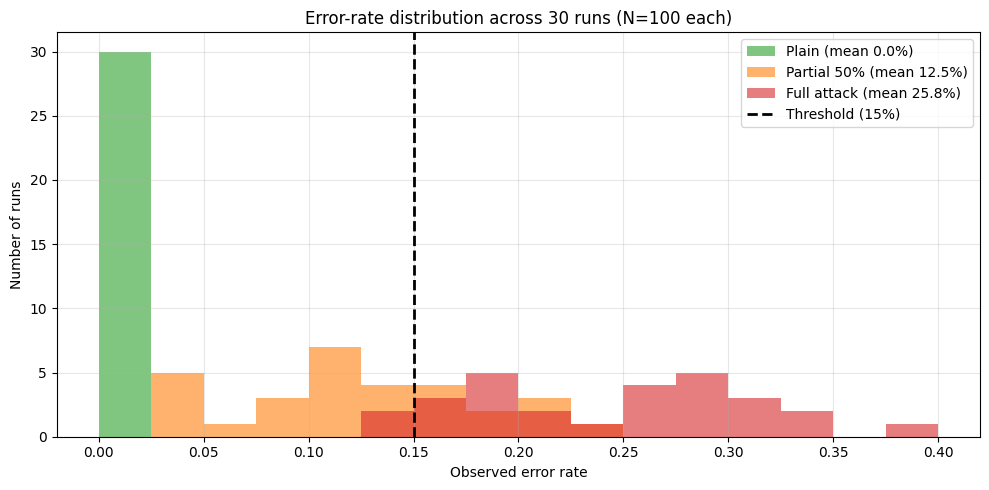

In [10]:
import matplotlib.pyplot as plt

# Cache the 8 possible single-qubit measurement circuits so we don't re-transpile every call.
_circ_cache = {}
def _measure_state(prep_bit, prep_basis, meas_basis):
    key = (prep_bit, prep_basis, meas_basis)
    if key not in _circ_cache:
        qc = QuantumCircuit(1, 1)
        if prep_bit == 1:
            qc.x(0)
        if prep_basis == 1:
            qc.h(0)
        if meas_basis == 1:
            qc.h(0)
        qc.measure(0, 0)
        _circ_cache[key] = transpile(qc, simulator)
    return int(simulator.run(_circ_cache[key], shots=1, memory=True).result().get_memory()[0])

def _batched_rng(n, chunk=20):
    bits = []
    while n > 0:
        k = min(chunk, n)
        qc = QuantumCircuit(k, k)
        for q in range(k):
            qc.h(q)
        qc.measure(range(k), range(k))
        bs = simulator.run(transpile(qc, simulator), shots=1, memory=True).result().get_memory()[0]
        bits.extend(int(c) for c in bs[::-1])
        n -= k
    return bits

def run_protocol(scenario, N=100):
    a_bits  = _batched_rng(N)
    a_bases = _batched_rng(N)
    b_bases = _batched_rng(N)

    if scenario == 'plain':
        b_bits = [_measure_state(a_bits[i], a_bases[i], b_bases[i]) for i in range(N)]
    else:
        e_bases = _batched_rng(N)
        attack_decisions = _batched_rng(N)
        b_bits = []
        for i in range(N):
            do_attack = scenario == 'full_attack' or (scenario == 'partial_attack' and attack_decisions[i] == 1)
            if do_attack:
                eve_bit = _measure_state(a_bits[i], a_bases[i], e_bases[i])
                b_bits.append(_measure_state(eve_bit, e_bases[i], b_bases[i]))
            else:
                b_bits.append(_measure_state(a_bits[i], a_bases[i], b_bases[i]))

    matching = [i for i in range(N) if a_bases[i] == b_bases[i]]
    a_sifted = [a_bits[i] for i in matching]
    b_sifted = [b_bits[i] for i in matching]
    check_idx = list(range(0, len(a_sifted), 2))
    if not check_idx:
        return 0.0
    return sum(1 for i in check_idx if a_sifted[i] != b_sifted[i]) / len(check_idx)

RUNS = 30
print(f"Running {RUNS} trials per scenario...")
plain_rates   = [run_protocol('plain')          for _ in range(RUNS)]
partial_rates = [run_protocol('partial_attack') for _ in range(RUNS)]
full_rates    = [run_protocol('full_attack')    for _ in range(RUNS)]
print(f"  plain   mean = {sum(plain_rates)/RUNS:.1%}")
print(f"  partial mean = {sum(partial_rates)/RUNS:.1%}")
print(f"  full    mean = {sum(full_rates)/RUNS:.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
bins = [i * 0.025 for i in range(17)]
ax.hist(plain_rates,   bins=bins, alpha=0.6, color='tab:green',  label=f'Plain (mean {sum(plain_rates)/RUNS:.1%})')
ax.hist(partial_rates, bins=bins, alpha=0.6, color='tab:orange', label=f'Partial 50% (mean {sum(partial_rates)/RUNS:.1%})')
ax.hist(full_rates,    bins=bins, alpha=0.6, color='tab:red',    label=f'Full attack (mean {sum(full_rates)/RUNS:.1%})')
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold ({THRESHOLD:.0%})')
ax.set_xlabel('Observed error rate')
ax.set_ylabel('Number of runs')
ax.set_title(f'Error-rate distribution across {RUNS} runs (N=100 each)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Notes

Full attack lands around 25% error and gets detected reliably (the histogram shows the plain and full-attack distributions sitting cleanly on opposite sides of the threshold). The partial attack at 50% sits around 12.5% and slips past, while Eve still ends up knowing ~25% of the key.

Not modelled here: real channel noise, smarter attacks (entangling probes, photon-number splitting), randomising which sifted bits are used as check bits.